In [69]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [3]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [5]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.526686,-1.344992,0.422481,1.787196,-2.063640,1
1,1.453861,-0.317411,-1.205825,0.891040,-0.154452,1
2,-3.772180,1.761945,0.644127,1.718029,1.524854,0
3,-1.315240,2.644472,0.506270,1.567917,-1.195466,0
4,-1.035752,0.656819,2.312906,-0.952793,-0.250113,0


In [7]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [113]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [11]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [137]:
df1 = combined_sampling(df,0.5,0.5)

In [141]:
df2 = combined_sampling(df,0.5,0.5)

In [145]:
df3 = combined_sampling(df,0.5,0.5)

In [147]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col2', 'target'], dtype='str')
Index(['col5', 'col2', 'target'], dtype='str')
Index(['col4', 'col1', 'target'], dtype='str')


In [157]:
df3

,col4,col1,target
6,0.519801,-0.575919,0
26,1.894276,1.825643,1
51,2.055978,2.368676,1
69,-0.171381,-0.410334,1
29,2.095000,3.115988,1
79,2.278905,-1.730884,0
39,0.194954,-2.192547,0
10,0.375703,-1.805158,0
80,-0.925277,0.921287,1
84,-0.441694,-1.360136,0


In [29]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [149]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [33]:
from sklearn.tree import plot_tree

[Text(0.3125, 0.9375, 'x[1] <= 0.889\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.25, 0.8125, 'x[1] <= -1.749\ngini = 0.43\nsamples = 32\nvalue = [10, 22]'),
 Text(0.28125, 0.875, 'True  '),
 Text(0.125, 0.6875, 'x[0] <= 1.828\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.0625, 0.5625, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.1875, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.6875, 'x[1] <= -1.613\ngini = 0.476\nsamples = 23\nvalue = [9, 14]'),
 Text(0.3125, 0.5625, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4375, 0.5625, 'x[0] <= 0.798\ngini = 0.42\nsamples = 20\nvalue = [6, 14]'),
 Text(0.1875, 0.4375, 'x[0] <= -0.088\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.125, 0.3125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.25, 0.3125, 'x[0] <= 0.247\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.1875, 0.1875, 'x[0] <= 0.087\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.125, 0.0625, 'gini = 0.0\ns

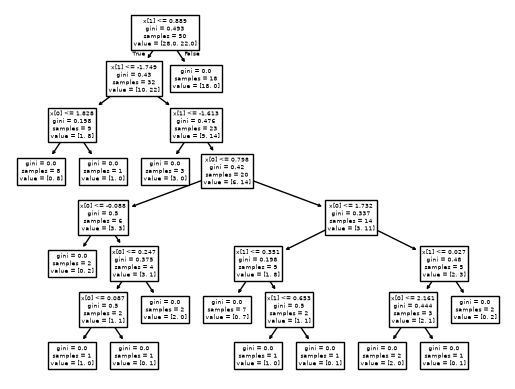

In [151]:
plot_tree(clf1)

[Text(0.6363636363636364, 0.9285714285714286, 'x[1] <= -0.046\ngini = 0.487\nsamples = 50\nvalue = [29.0, 21.0]'),
 Text(0.45454545454545453, 0.7857142857142857, 'x[0] <= -0.229\ngini = 0.375\nsamples = 24\nvalue = [6, 18]'),
 Text(0.5454545454545454, 0.8571428571428572, 'True  '),
 Text(0.36363636363636365, 0.6428571428571429, 'x[1] <= -0.213\ngini = 0.49\nsamples = 14\nvalue = [6, 8]'),
 Text(0.2727272727272727, 0.5, 'x[1] <= -0.504\ngini = 0.496\nsamples = 11\nvalue = [6, 5]'),
 Text(0.18181818181818182, 0.35714285714285715, 'x[0] <= -3.092\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.09090909090909091, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2727272727272727, 0.21428571428571427, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.36363636363636365, 0.35714285714285715, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.45454545454545453, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5454545454545454, 0.6428571428571429, 'gini =

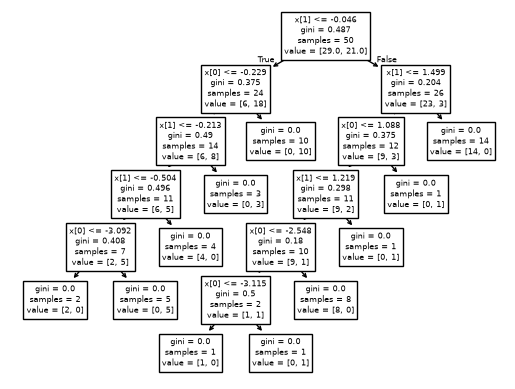

In [153]:
plot_tree(clf2)

[Text(0.5, 0.875, 'x[1] <= -0.493\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2, 0.625, 'x[1] <= -0.989\ngini = 0.077\nsamples = 25\nvalue = [24, 1]'),
 Text(0.35, 0.75, 'True  '),
 Text(0.1, 0.375, 'gini = 0.0\nsamples = 18\nvalue = [18, 0]'),
 Text(0.3, 0.375, 'x[1] <= -0.942\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.8, 0.625, 'x[1] <= -0.038\ngini = 0.077\nsamples = 25\nvalue = [1, 24]'),
 Text(0.65, 0.75, '  False'),
 Text(0.7, 0.375, 'x[1] <= -0.111\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.9, 0.375, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]')]

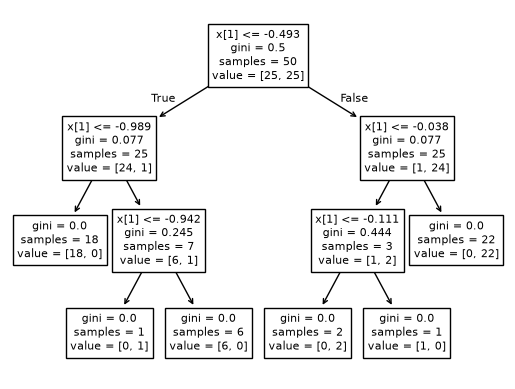

In [155]:
plot_tree(clf3)

In [61]:
clf1.predict(np.array([0.526686,	-1.344992,	0.422481,	1.787196,	-2.063640]).reshape(1,5))

C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [63]:
clf2.predict(np.array([0.526686,	-1.344992,	0.422481,	1.787196,	-2.063640]).reshape(1,5))

C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [161]:
clf3.predict(np.array([1.894276,	1.825643]).reshape(1,2))

C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])